# Notebook 07 · Conectividad digital y telecomunicaciones en Iberia

En este notebook preparamos el bloque de conectividad digital para el análisis territorial de CPD sostenibles en España peninsular, Portugal continental y Andorra.

Integramos información de OpenStreetMap, PeeringDB y RIPE Atlas. OpenStreetMap aporta la infraestructura de telecomunicaciones cartografiada, mientras que PeeringDB y RIPE Atlas se conservan como fuentes complementarias de conectividad digital.

Primero reutilizamos los datos procesados disponibles en Kaggle Input y mantenemos las APIs como alternativa cuando estos archivos no están disponibles.

Los resultados los utilizamos para construir indicadores territoriales de conectividad digital. En el modelo final emepleamos variables relacionadas con CPD identificados en OSM, torres y mástiles de comunicación y centrales de telecomunicaciones.

Estas fuentes representan infraestructura observable en datos abiertos, pero no describen toda la red privada de fibra ni permiten medir la latencia, el ancho de banda disponible o la redundancia real de las conexiones.


In [1]:
# LIBRERÍAS GEOESPACIALES
%pip install -q geopandas pyogrio folium requests tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
# LIBRERÍAS
from pathlib import Path
from datetime import datetime
import os
import time
import json
import zipfile
import base64
import re

import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium

from shapely.geometry import Point, LineString, Polygon, box
from tqdm.auto import tqdm

In [3]:
# CONFIGURACIÓN
NOMBRE_BLOQUE = "07_conectividad_digital_telecomunicaciones_iberia"
BASE_DIR = Path("/kaggle/working") / NOMBRE_BLOQUE

RAW_DIR = BASE_DIR / "raw"
RAW_OSM_DIR = RAW_DIR / "osm_overpass"
RAW_PEERINGDB_DIR = RAW_DIR / "peeringdb"
RAW_RIPE_ATLAS_DIR = RAW_DIR / "ripe_atlas"

PROCESSED_DIR = BASE_DIR / "processed"
GPKG_DIR = PROCESSED_DIR / "geopackage"
FIGURAS_DIR = BASE_DIR / "figuras"
FIGURES_DIR = FIGURAS_DIR
DASHBOARD_DIR = BASE_DIR / "dashboard"
TABLAS_DIR = BASE_DIR / "tablas"
MANIFEST_DIR = BASE_DIR / "manifest"
LOGS_DIR = BASE_DIR / "logs"

for carpeta in [
    RAW_OSM_DIR,
    RAW_PEERINGDB_DIR,
    RAW_RIPE_ATLAS_DIR,
    GPKG_DIR,
    FIGURAS_DIR,
    DASHBOARD_DIR,
    TABLAS_DIR,
    MANIFEST_DIR,
    LOGS_DIR
]:
    carpeta.mkdir(parents=True, exist_ok=True)

FECHA_EJECUCION = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
FECHA_DESCARGA = FECHA_EJECUCION[:10]

print("Salida:", BASE_DIR)
print("Fecha:", FECHA_EJECUCION)

Salida: /kaggle/working/07_conectividad_digital_telecomunicaciones_iberia
Fecha: 2026-09-13 13:08:11


## Fuentes y criterio temporal

Integramos tres fuentes abiertas de conectividad digital:

* OpenStreetMap / Overpass: infraestructura de telecomunicaciones cartografiada.
* PeeringDB: facilities y puntos de intercambio de Internet como información complementaria.
* RIPE Atlas: probes activos como señal complementaria de conectividad.

Primero reutilizamos los datos procesados disponibles en Kaggle Input. Las APIs las mantenemos como alternativa si estos archivos no están disponibles.

Tratamos esta información como cartografía semiestática y documentamos su fecha de consulta. No aplicamos una ventana temporal climática.

En el modelo final, los indicadores territoriales de conectividad digital se construyen a partir de OpenStreetMap mediante el número de CPD identificados y las densidades de torres y mástiles de comunicación y de centrales de telecomunicaciones.

PeeringDB y RIPE Atlas los guardamos como información complementaria y de contraste. Estas fuentes abiertas no representan toda la red privada de fibra ni permiten medir directamente la latencia, el ancho de banda disponible o la redundancia real de las conexiones.

In [4]:
# DATOS DISPONIBLES EN KAGGLE INPUT
INPUT_DIR = Path("/kaggle/input")

archivos_clave = [
    "nodos_digitales_unificados_definitivo_notebook_07.gpkg",
    "nodos_digitales_unificados_definitivo_notebook_07_epsg3035.gpkg",
    "osm_overpass_telecom_iberia_recortado_modelo.gpkg",
    "osm_overpass_telecom_iberia_recortado_modelo_epsg3035.gpkg",
    "resumen_conectividad_digital_iberia_definitivo_estricto_notebook_07.csv",
    "log_descarga_osm_overpass_telecom_126_teselas.csv"
]
rutas_input = {
    archivo: next(INPUT_DIR.rglob(archivo), None)
    for archivo in archivos_clave
}
ids_teselas = {
    resultado.group()
    for ruta in INPUT_DIR.rglob("overpass_telecom_tile_*.json")
    if (resultado := re.search(r"tile_\d{4}", ruta.name))
}
USAR_INPUT_FINAL = all(rutas_input.values())
control_input = pd.DataFrame({
    "archivo": rutas_input.keys(),
    "existe": [ruta is not None for ruta in rutas_input.values()],
    "ruta": [str(ruta or "") for ruta in rutas_input.values()]
})
print("Usar Kaggle Input:", USAR_INPUT_FINAL)
print("Teselas OSM:", len(ids_teselas))
display(control_input)

Usar Kaggle Input: True
Teselas OSM: 126


,archivo,existe,ruta
0,nodos_digitales_unificados_definitivo_notebook...,True,/kaggle/input/datasets/aemjeloy/07-conectivida...
1,nodos_digitales_unificados_definitivo_notebook...,True,/kaggle/input/datasets/aemjeloy/07-conectivida...
2,osm_overpass_telecom_iberia_recortado_modelo.gpkg,True,/kaggle/input/datasets/aemjeloy/07-conectivida...
3,osm_overpass_telecom_iberia_recortado_modelo_e...,True,/kaggle/input/datasets/aemjeloy/07-conectivida...
4,resumen_conectividad_digital_iberia_definitivo...,True,/kaggle/input/datasets/aemjeloy/07-conectivida...
5,log_descarga_osm_overpass_telecom_126_teselas.csv,True,/kaggle/input/datasets/aemjeloy/07-conectivida...


In [5]:
# CONFIGURACIÓN ESPACIAL
CRS_GEOGRAFICO = "EPSG:4326"
CRS_EUROPEO_AREA = "EPSG:3035"
OESTE, SUR, ESTE, NORTE = -10.0, 35.0, 4.0, 44.0
BBOX_OVERPASS = f"{SUR},{OESTE},{NORTE},{ESTE}"

bbox_estudio_gdf = gpd.GeoDataFrame(
    {"nombre": ["Iberia y Andorra"]},
    geometry=[box(OESTE, SUR, ESTE, NORTE)],
    crs=CRS_GEOGRAFICO
)
print("BBOX Overpass:", BBOX_OVERPASS)
print("CRS:", CRS_GEOGRAFICO, "/", CRS_EUROPEO_AREA)

BBOX Overpass: 35.0,-10.0,44.0,4.0
CRS: EPSG:4326 / EPSG:3035


In [6]:
# ALTERNATIVA OSM / OVERPASS
if USAR_INPUT_FINAL:
    print("5B omitida: utilizamos Kaggle Input.")
else:
    from shutil import copy2
    teselas = pd.DataFrame([
        {
            "id_tesela": f"tile_{n:04d}",
            "bbox_overpass": f"{lat},{lon},{lat + 1},{lon + 1}"
        }
        for n, (lat, lon) in enumerate(
            [
                (lat, lon)
                for lat in range(int(SUR), int(NORTE))
                for lon in range(int(OESTE), int(ESTE))
            ],
            start=1
        )
    ])
    filtros = [
        ("communication", "line"),
        ("telecom", "line"),
        ("telecom", "path"),
        ("telecom:medium", "fibre"),
        ("telecom:medium", "fiber"),
        ("telecom", "exchange"),
        ("telecom", "central_office"),
        ("telecom", "data_center"),
        ("building", "data_center"),
        ("telecom", "distribution_point"),
        ("telecom", "connection_point"),
        ("telecom", "service_device"),
        ("telecom", "cable_landing_station"),
        ("man_made", "communications_tower"),
        ("tower:type", "communication"),
        ("office", "telecommunication")
    ]
    endpoints = [
        "https://overpass-api.de/api/interpreter",
        "https://overpass.kumi.systems/api/interpreter"
    ]

    def consulta_overpass(bbox):
        elementos = "".join(
            f'nwr["{clave}"="{valor}"]({bbox});'
            for clave, valor in filtros
        )
        return (
            f"[out:json][timeout:180];({elementos});"
            "out body;>;out skel qt;"
        )

    def descargar_tesela(id_tesela, bbox):
        ruta_json = (
            RAW_OSM_DIR /
            f"overpass_telecom_{id_tesela}.json"
        )

        # Reutilizar caché local o de Kaggle Input
        if not ruta_json.exists():
            ruta_input = next(
                INPUT_DIR.rglob(ruta_json.name),
                None
            )
            if ruta_input:
                copy2(ruta_input, ruta_json)
        if ruta_json.exists():
            datos = json.loads(
                ruta_json.read_text(encoding="utf-8")
            )
            return {
                "id_tesela": id_tesela,
                "bbox_overpass": bbox,
                "estado_descarga": "correcta_cache",
                "numero_elementos": len(datos["elements"]),
                "ruta_json": str(ruta_json)
            }
        error = ""

        for _ in range(2):
            for endpoint in endpoints:
                try:
                    respuesta = requests.post(
                        endpoint,
                        data={"data": consulta_overpass(bbox)},
                        timeout=240
                    )
                    if respuesta.ok:
                        datos = respuesta.json()
                        ruta_json.write_text(
                            json.dumps(datos),
                            encoding="utf-8"
                        )
                        return {
                            "id_tesela": id_tesela,
                            "bbox_overpass": bbox,
                            "estado_descarga": "correcta",
                            "numero_elementos": len(datos["elements"]),
                            "ruta_json": str(ruta_json)
                        }
                    error = f"HTTP {respuesta.status_code}"
                except Exception as excepcion:
                    error = str(excepcion)
                time.sleep(5)
        return {
            "id_tesela": id_tesela,
            "bbox_overpass": bbox,
            "estado_descarga": "fallida",
            "numero_elementos": 0,
            "ruta_json": "",
            "error": error
        }
    resultados = []
    ruta_log = (
        LOGS_DIR /
        "log_descarga_osm_overpass_telecom_126_teselas.csv"
    )
    for fila in tqdm(teselas.itertuples(index=False), total=126):
        resultados.append(
            descargar_tesela(
                fila.id_tesela,
                fila.bbox_overpass
            )
        )
        pd.DataFrame(resultados).to_csv(
            ruta_log,
            index=False
        )
    log_osm = pd.DataFrame(resultados)
    correctas = log_osm["estado_descarga"].isin(
        ["correcta", "correcta_cache"]
    ).sum()
    if correctas != 126:
        raise RuntimeError(
            f"Descarga OSM incompleta: {correctas}/126."
        )
    ORIGEN_DATOS = "APIs"
    print("Teselas OSM disponibles:", correctas)

5B omitida: utilizamos Kaggle Input.


In [7]:
# ALTERNATIVA PEERINGDB Y RIPE ATLAS
if USAR_INPUT_FINAL:
    print("5C omitida: utilizamos Kaggle Input.")
else:
    paises = ["ES", "PT", "AD"]
    
    def consultar_api(url, parametros):
        respuesta = requests.get(
            url,
            params=parametros,
            timeout=120
        )
        respuesta.raise_for_status()
        return respuesta.json()

    # PeeringDB
    def descargar_peeringdb(endpoint):
        tablas = []
        for pais in paises:
            datos = consultar_api(
                f"https://www.peeringdb.com/api/{endpoint}",
                {"country": pais}
            )
            tablas.append(
                pd.DataFrame(datos["data"]).assign(
                    pais_codigo_consulta=pais
                )
            )
        return pd.concat(tablas, ignore_index=True)
        
    peeringdb_fac_df = descargar_peeringdb("fac")
    peeringdb_ix_df = descargar_peeringdb("ix")
    peeringdb_fac_df["latitude"] = pd.to_numeric(
        peeringdb_fac_df["latitude"],
        errors="coerce"
    )
    peeringdb_fac_df["longitude"] = pd.to_numeric(
        peeringdb_fac_df["longitude"],
        errors="coerce"
    )
    facilities = peeringdb_fac_df.dropna(
        subset=["latitude", "longitude"]
    )
    peeringdb_fac_gdf = gpd.GeoDataFrame(
        facilities,
        geometry=gpd.points_from_xy(
            facilities["longitude"],
            facilities["latitude"]
        ),
        crs=CRS_GEOGRAFICO
    )

    # RIPE Atlas
    registros_ripe = []
    for pais in paises:
        url = "https://atlas.ripe.net/api/v2/probes/"
        parametros = {
            "country_code": pais,
            "status": 1,
            "page_size": 500
        }
        while url:
            datos = consultar_api(url, parametros)
            for registro in datos["results"]:
                registro["pais_codigo_consulta"] = pais
                registros_ripe.append(registro)
            url = datos.get("next")
            parametros = None
    ripe_df = pd.DataFrame(registros_ripe)
    coordenadas = ripe_df["geometry"].str["coordinates"]
    ripe_df["longitude"] = coordenadas.str[0]
    ripe_df["latitude"] = coordenadas.str[1]
    ripe_gdf = gpd.GeoDataFrame(
        ripe_df.drop(columns="geometry"),
        geometry=gpd.points_from_xy(
            ripe_df["longitude"],
            ripe_df["latitude"]
        ),
        crs=CRS_GEOGRAFICO
    )

    # Guardar datos y log
    peeringdb_fac_df.to_json(
        RAW_PEERINGDB_DIR / "peeringdb_facilities_iberia.json",
        orient="records"
    )
    peeringdb_ix_df.to_csv(
        TABLAS_DIR / "peeringdb_ix_iberia.csv",
        index=False
    )
    ripe_df.to_json(
        RAW_RIPE_ATLAS_DIR / "ripe_atlas_probes_iberia.json",
        orient="records"
    )
    pd.DataFrame({
        "fuente": ["PeeringDB", "RIPE Atlas"],
        "registros": [
            len(peeringdb_fac_gdf),
            len(ripe_gdf)
        ]
    }).to_csv(
        LOGS_DIR / "log_descarga_peeringdb_ripe_atlas.csv",
        index=False
    )
    print("PeeringDB:", len(peeringdb_fac_gdf))
    print("RIPE Atlas:", len(ripe_gdf))

5C omitida: utilizamos Kaggle Input.


### Recorte territorial

Las capas finales se limitan a España peninsular, Portugal continental y Andorra. Si se utilizan las APIs, el recorte se realiza mediante una máscara territorial; si se utiliza Kaggle Input, las capas ya están procesadas y recortadas.

In [8]:
# Procesamiento alternativo de los datos descargados
if USAR_INPUT_FINAL:
    print("5D omitida: utilizamos Kaggle Input.")
else:
    print("Procesando datos descargados desde las APIs...")

    # Procesar los 126 JSON de OSM
    rutas_json = sorted(
        RAW_OSM_DIR.glob("overpass_telecom_tile_*.json")
    )
    if len(rutas_json) != 126:
        raise RuntimeError(
            f"JSON OSM encontrados: {len(rutas_json)} de 126."
        )

    def es_telecom(tags):
        return (
            tags.get("communication") == "line"
            or tags.get("telecom") in [
                "line", "path", "exchange", "central_office",
                "data_center", "distribution_point",
                "connection_point", "service_device",
                "cable_landing_station"
            ]
            or tags.get("telecom:medium") in ["fibre", "fiber"]
            or tags.get("building") == "data_center"
            or tags.get("man_made") == "communications_tower"
            or tags.get("tower:type") == "communication"
            or tags.get("office") == "telecommunication"
        )

    def clasificar_osm(tags):
        telecom = tags.get("telecom")
        if telecom == "data_center" or tags.get("building") == "data_center":
            return "data_center_osm"
        if telecom in ["exchange", "central_office"]:
            return "exchange_central_telecom"
        if telecom in [
            "distribution_point",
            "connection_point",
            "service_device"
        ]:
            return "nodo_distribucion_telecom"
        if telecom == "cable_landing_station":
            return "estacion_amarre_cable"
        if (
            tags.get("communication") == "line"
            or telecom in ["line", "path"]
            or tags.get("telecom:medium") in ["fibre", "fiber"]
        ):
            return "linea_fibra_telecom"
        return "torre_o_nodo_telecom"

    def registro_osm(elemento, tags, tesela, tipo, geometria):
        return {
            "id_tesela": tesela,
            "osm_id": elemento["id"],
            "tipo_osm": elemento["type"],
            "tipo_geometria": tipo,
            "name": tags.get("name"),
            "operator": tags.get("operator"),
            "telecom": tags.get("telecom"),
            "communication": tags.get("communication"),
            "telecom_medium": tags.get("telecom:medium"),
            "tipo_modelo": clasificar_osm(tags),
            "fuente": "OpenStreetMap Overpass",
            "geometry": geometria
        }
    puntos, lineas, poligonos = [], [], []

    for ruta in tqdm(rutas_json, desc="Procesando OSM"):
        tesela = re.search(r"tile_\d{4}", ruta.name).group()
        with open(ruta, encoding="utf-8") as archivo:
            elementos = json.load(archivo).get("elements", [])
        coordenadas = {
            e["id"]: (e["lon"], e["lat"])
            for e in elementos
            if e.get("type") == "node"
            and "lon" in e
            and "lat" in e
        }

        for elemento in elementos:
            tags = elemento.get("tags", {})

            if not es_telecom(tags):
                continue
            if elemento["type"] == "node":
                geometria = Point(coordenadas[elemento["id"]])
                puntos.append(
                    registro_osm(
                        elemento, tags, tesela,
                        "punto_osm", geometria
                    )
                )
            elif elemento["type"] == "way":
                coords = [
                    coordenadas[nodo]
                    for nodo in elemento.get("nodes", [])
                    if nodo in coordenadas
                ]
                if len(coords) < 2:
                    continue
                if len(coords) >= 4 and coords[0] == coords[-1]:
                    geometria = Polygon(coords)
                    if geometria.is_valid:
                        poligonos.append(
                            registro_osm(
                                elemento, tags, tesela,
                                "poligono_osm", geometria
                            )
                        )
                        puntos.append(
                            registro_osm(
                                elemento, tags, tesela,
                                "punto_representativo",
                                geometria.representative_point()
                            )
                        )
                else:
                    geometria = LineString(coords)
                    if geometria.is_valid:
                        lineas.append(
                            registro_osm(
                                elemento, tags, tesela,
                                "linea_osm", geometria
                            )
                        )

    def crear_gdf(registros):
        gdf = gpd.GeoDataFrame(
            registros,
            geometry="geometry",
            crs=CRS_GEOGRAFICO
        )
        return gdf.drop_duplicates(
            ["tipo_osm", "osm_id", "tipo_geometria"]
        ).reset_index(drop=True)
    osm_puntos = crear_gdf(puntos)
    osm_lineas = crear_gdf(lineas)
    osm_poligonos = crear_gdf(poligonos)

    # Máscara de España peninsular, Portugal y Andorra
    nombre_mascara = (
        "mascara_territorial_iberia_andorra_notebook_07.gpkg"
    )
    ruta_mascara_input = next(
        INPUT_DIR.rglob(nombre_mascara),
        None
    )
    if ruta_mascara_input:
        mascara = gpd.read_file(
            ruta_mascara_input,
            layer="mascara_territorial_iberia_andorra"
        )
    else:
        url = (
            "https://naturalearth.s3.amazonaws.com/"
            "10m_cultural/ne_10m_admin_0_countries.zip"
        )
        paises = gpd.read_file(url).to_crs(CRS_GEOGRAFICO)
        codigos = {"ESP": "ES", "PRT": "PT", "AND": "AD"}
        paises["codigo_pais"] = paises["ADM0_A3"].map(codigos)
        paises = (
            paises[paises["codigo_pais"].notna()]
            .explode(index_parts=False)
            .reset_index(drop=True)
        )
        paises["area"] = (
            paises.to_crs(CRS_EUROPEO_AREA).geometry.area.values
        )
        mascara = (
            paises.sort_values("area")
            .groupby("codigo_pais")
            .tail(1)[["codigo_pais", "geometry"]]
        )
    mascara = gpd.GeoDataFrame(
        mascara,
        geometry="geometry",
        crs=CRS_GEOGRAFICO
    )
    ruta_mascara = GPKG_DIR / nombre_mascara
    mascara.to_file(
        ruta_mascara,
        layer="mascara_territorial_iberia_andorra",
        driver="GPKG"
    )
    union_mascara = mascara.geometry.union_all()

    def filtrar_puntos(gdf):
        return gdf[
            gdf.geometry.notna()
            & ~gdf.geometry.is_empty
            & gdf.geometry.intersects(union_mascara)
        ].copy().reset_index(drop=True)
    osm_puntos = filtrar_puntos(osm_puntos)
    osm_lineas = gpd.clip(osm_lineas, mascara)
    osm_poligonos = gpd.clip(osm_poligonos, mascara)
    peeringdb = filtrar_puntos(peeringdb_fac_gdf)
    ripe = filtrar_puntos(ripe_gdf)

    # Unir las tres fuentes
    nombres_paises = {
        "ES": "España",
        "PT": "Portugal",
        "AD": "Andorra"
    }

    def obtener_pais(geometria):
        for fila in mascara.itertuples():
            if geometria.intersects(fila.geometry):
                return fila.codigo_pais
        return None

    nodos = []
    for fila in osm_puntos.itertuples():
        codigo = obtener_pais(fila.geometry)
        nodos.append({
            "id_origen": f"osm_{fila.tipo_osm}_{fila.osm_id}",
            "nombre": fila.name,
            "ciudad": None,
            "pais_codigo": codigo,
            "pais_nombre": nombres_paises.get(codigo),
            "fuente": "OpenStreetMap Overpass",
            "tipo_fuente": "osm_overpass_telecom",
            "categoria_conectividad": "OSM telecom point",
            "id_tesela": fila.id_tesela,
            "tipo_modelo": fila.tipo_modelo,
            "observacion": "Elemento OSM dentro del área de estudio.",
            "geometry": fila.geometry
        })
    for fila in peeringdb.itertuples():
        codigo = obtener_pais(fila.geometry)
        nodos.append({
            "id_origen": f"peeringdb_{fila.id}",
            "nombre": fila.name,
            "ciudad": getattr(fila, "city", None),
            "pais_codigo": codigo,
            "pais_nombre": nombres_paises.get(codigo),
            "fuente": "PeeringDB",
            "tipo_fuente": "peeringdb_facility",
            "categoria_conectividad": "PeeringDB facility",
            "id_tesela": None,
            "tipo_modelo": "facility_interconexion_datacenter",
            "observacion": "Facility con coordenadas directas.",
            "geometry": fila.geometry
        })
    for fila in ripe.itertuples():
        codigo = obtener_pais(fila.geometry)
        nodos.append({
            "id_origen": f"ripe_{fila.id}",
            "nombre": f"RIPE Atlas probe {fila.id}",
            "ciudad": None,
            "pais_codigo": codigo,
            "pais_nombre": nombres_paises.get(codigo),
            "fuente": "RIPE Atlas",
            "tipo_fuente": "ripe_atlas_probe",
            "categoria_conectividad": "RIPE Atlas probe",
            "id_tesela": None,
            "tipo_modelo": "probe_medicion_conectividad",
            "observacion": "Probe activo dentro del área de estudio.",
            "geometry": fila.geometry
        })
    nodos_gdf = gpd.GeoDataFrame(
        nodos,
        geometry="geometry",
        crs=CRS_GEOGRAFICO
    )

    # Guardar salidas compatibles
    rutas_input = {
        "nodos_4326": GPKG_DIR /
            "nodos_digitales_unificados_definitivo_notebook_07.gpkg",
        "nodos_3035": GPKG_DIR /
            "nodos_digitales_unificados_definitivo_notebook_07_epsg3035.gpkg",
        "osm_4326": GPKG_DIR /
            "osm_overpass_telecom_iberia_recortado_modelo.gpkg",
        "osm_3035": GPKG_DIR /
            "osm_overpass_telecom_iberia_recortado_modelo_epsg3035.gpkg",
        "resumen": TABLAS_DIR /
            "resumen_conectividad_digital_iberia_definitivo_estricto_notebook_07.csv",
        "log_osm": LOGS_DIR /
            "log_descarga_osm_overpass_telecom_126_teselas.csv"
    }
    nodos_gdf.to_file(
        rutas_input["nodos_4326"],
        layer="nodos_digitales_modelo",
        driver="GPKG"
    )
    nodos_gdf.to_crs(CRS_EUROPEO_AREA).to_file(
        rutas_input["nodos_3035"],
        layer="nodos_digitales_modelo",
        driver="GPKG"
    )
    capas_osm = {
        "osm_puntos_telecom_modelo": osm_puntos,
        "osm_lineas_telecom_modelo": osm_lineas,
        "osm_poligonos_telecom_modelo": osm_poligonos
    }
    for ruta, crs in [
        (rutas_input["osm_4326"], CRS_GEOGRAFICO),
        (rutas_input["osm_3035"], CRS_EUROPEO_AREA)
    ]:
        for nombre, capa in capas_osm.items():
            capa.to_crs(crs).to_file(
                ruta,
                layer=nombre,
                driver="GPKG"
            )
    resumen_api = pd.DataFrame([{
        "origen": "APIs",
        "teselas_osm": len(rutas_json),
        "osm_puntos_recortados_modelo": len(osm_puntos),
        "osm_lineas_recortadas_modelo": len(osm_lineas),
        "osm_poligonos_recortados_modelo": len(osm_poligonos),
        "peeringdb_facilities_modelo_estricto": len(peeringdb),
        "ripe_probes_modelo_estricto": len(ripe),
        "nodos_digitales_definitivos_estrictos": len(nodos_gdf),
        "fecha_ejecucion": FECHA_EJECUCION
    }])
    resumen_api.to_csv(
        rutas_input["resumen"],
        index=False,
        encoding="utf-8-sig"
    )
    ORIGEN_DATOS = "APIs"

    print("5D completada.")
    print("Nodos digitales:", len(nodos_gdf))

5D omitida: utilizamos Kaggle Input.


In [9]:
# CARGA DE DATOS FINALES
archivos_finales = {
    "nodos_4326":
        "nodos_digitales_unificados_definitivo_notebook_07.gpkg",
    "nodos_3035":
        "nodos_digitales_unificados_definitivo_notebook_07_epsg3035.gpkg",
    "osm_4326":
        "osm_overpass_telecom_iberia_recortado_modelo.gpkg",
    "osm_3035":
        "osm_overpass_telecom_iberia_recortado_modelo_epsg3035.gpkg",
    "resumen":
        "resumen_conectividad_digital_iberia_definitivo_estricto_notebook_07.csv",
    "log_osm":
        "log_descarga_osm_overpass_telecom_126_teselas.csv"
}

def localizar_archivo(nombre):
    for carpeta in [GPKG_DIR, TABLAS_DIR, LOGS_DIR, INPUT_DIR]:
        ruta = next(carpeta.rglob(nombre), None)
        if ruta:
            return ruta
    return None
rutas_input = {
    clave: localizar_archivo(nombre)
    for clave, nombre in archivos_finales.items()
}
if not all(rutas_input.values()):
    raise FileNotFoundError("Faltan archivos finales del bloque 07.")
nodos_digitales_gdf = gpd.read_file(
    rutas_input["nodos_4326"],
    layer="nodos_digitales_modelo"
)
nodos_digitales_3035 = gpd.read_file(
    rutas_input["nodos_3035"],
    layer="nodos_digitales_modelo"
)

osm_puntos_gdf = gpd.read_file(
    rutas_input["osm_4326"],
    layer="osm_puntos_telecom_modelo"
)
osm_lineas_gdf = gpd.read_file(
    rutas_input["osm_4326"],
    layer="osm_lineas_telecom_modelo"
)
osm_poligonos_gdf = gpd.read_file(
    rutas_input["osm_4326"],
    layer="osm_poligonos_telecom_modelo"
)
resumen_conectividad = pd.read_csv(rutas_input["resumen"])
log_osm = pd.read_csv(rutas_input["log_osm"])

ORIGEN_DATOS = "Kaggle Input" if USAR_INPUT_FINAL else "APIs"

print("Origen:", ORIGEN_DATOS)
print("Nodos digitales:", len(nodos_digitales_gdf))
print("Teselas OSM:", len(log_osm))

Origen: Kaggle Input
Nodos digitales: 16775
Teselas OSM: 126


In [10]:
# COMPROBAR CONTEOS FINALES
conteo_actual = nodos_digitales_gdf["fuente"].value_counts()
comparacion_conteos = pd.DataFrame({
    "fuente": [
        "OpenStreetMap Overpass",
        "PeeringDB",
        "RIPE Atlas"
    ],
    "actual": [
        conteo_actual.get("OpenStreetMap Overpass", 0),
        conteo_actual.get("PeeringDB", 0),
        conteo_actual.get("RIPE Atlas", 0)
    ],
    "esperado": [
        resumen_conectividad.loc[
            0, "osm_puntos_recortados_modelo"
        ],
        resumen_conectividad.loc[
            0, "peeringdb_facilities_modelo_estricto"
        ],
        resumen_conectividad.loc[
            0, "ripe_probes_modelo_estricto"
        ]
    ]
})
comparacion_conteos["diferencia"] = (
    comparacion_conteos["actual"]
    - comparacion_conteos["esperado"]
)
display(comparacion_conteos)

,fuente,actual,esperado,diferencia
0,OpenStreetMap Overpass,16364,16364,0
1,PeeringDB,76,76,0
2,RIPE Atlas,335,335,0


In [11]:
# CONTROL DE CALIDAD
capas = [
    ("nodos_4326", nodos_digitales_gdf, 4326),
    ("nodos_3035", nodos_digitales_3035, 3035),
    ("osm_puntos", osm_puntos_gdf, 4326),
    ("osm_lineas", osm_lineas_gdf, 4326),
    ("osm_poligonos", osm_poligonos_gdf, 4326)
]
control_calidad = pd.DataFrame([
    {
        "capa": nombre,
        "registros": len(gdf),
        "epsg": gdf.crs.to_epsg(),
        "nulas": int(gdf.geometry.isna().sum()),
        "vacias": int(gdf.geometry.is_empty.sum()),
        "invalidas": int((~gdf.geometry.is_valid).sum()),
        "estado": (
            "correcta"
            if len(gdf) > 0
            and gdf.crs.to_epsg() == epsg
            and gdf.geometry.isna().sum() == 0
            and gdf.geometry.is_empty.sum() == 0
            and (~gdf.geometry.is_valid).sum() == 0
            else "revisar"
        )
    }
    for nombre, gdf, epsg in capas
])
resumen_fuentes = (
    nodos_digitales_gdf["fuente"]
    .value_counts()
    .rename_axis("fuente")
    .reset_index(name="registros")
)
control_calidad.to_csv(
    TABLAS_DIR / "tabla_control_calidad_conectividad_digital.csv",
    index=False
)
resumen_fuentes.to_csv(
    TABLAS_DIR / "tabla_resumen_fuentes_nodos_digitales.csv",
    index=False
)

print("Nodos digitales:", len(nodos_digitales_gdf))
display(control_calidad)
display(resumen_fuentes)

Nodos digitales: 16775


,capa,registros,epsg,nulas,vacias,invalidas,estado
0,nodos_4326,16775,4326,0,0,0,correcta
1,nodos_3035,16775,3035,0,0,0,correcta
2,osm_puntos,16364,4326,0,0,0,correcta
3,osm_lineas,153,4326,0,0,0,correcta
4,osm_poligonos,584,4326,0,0,0,correcta


,fuente,registros
0,OpenStreetMap Overpass,16364
1,RIPE Atlas,335
2,PeeringDB,76


### Validación de Andorra

Comprobamos la cobertura de Andorra sobre las capas finales, tanto si proceden de Kaggle Input como de las APIs alternativas.

La validación confirma la presencia de infraestructura digital cartografiada, pero no garantiza capacidad, latencia ni disponibilidad real de conexión.

In [12]:
# VALIDACIÓN DE ANDORRA
nodos_andorra_gdf = nodos_digitales_gdf[
    nodos_digitales_gdf["pais_codigo"] == "AD"
].copy()
resumen_andorra = (
    nodos_andorra_gdf["fuente"]
    .value_counts()
    .rename_axis("fuente")
    .reset_index(name="registros")
)
estado_andorra = pd.DataFrame([{
    "territorio": "Andorra",
    "nodos_digitales": len(nodos_andorra_gdf),
    "fuentes_presentes": resumen_andorra["fuente"].nunique(),
    "estado": (
        "cobertura_disponible"
        if len(nodos_andorra_gdf) > 0
        else "sin_cobertura"
    )
}])
resumen_andorra.to_csv(
    TABLAS_DIR / "tabla_nodos_digitales_andorra_por_fuente.csv",
    index=False
)
estado_andorra.to_csv(
    TABLAS_DIR / "tabla_estado_conectividad_andorra.csv",
    index=False
)
print("Nodos digitales en Andorra:", len(nodos_andorra_gdf))
display(resumen_andorra)
display(estado_andorra)

Nodos digitales en Andorra: 7


,fuente,registros
0,OpenStreetMap Overpass,4
1,RIPE Atlas,3


,territorio,nodos_digitales,fuentes_presentes,estado
0,Andorra,7,2,cobertura_disponible


### Integración de nodos digitales

La capa final integra los puntos de telecomunicaciones de OSM, las facilities de PeeringDB y los probes activos de RIPE Atlas. Las líneas y polígonos de OSM se mantienen como capas auxiliares separadas.

In [13]:
# GUARDAMOS RESULTADOS
import shutil
destinos = {
    "nodos_4326":
        "nodos_digitales_unificados_definitivo_notebook_07.gpkg",
    "nodos_3035":
        "nodos_digitales_unificados_definitivo_notebook_07_epsg3035.gpkg",
    "osm_4326":
        "osm_overpass_telecom_iberia_recortado_modelo.gpkg",
    "osm_3035":
        "osm_overpass_telecom_iberia_recortado_modelo_epsg3035.gpkg"
}
for clave, nombre in destinos.items():
    origen = Path(rutas_input[clave])
    destino = GPKG_DIR / nombre
    if origen.resolve() != destino.resolve():
        shutil.copy2(origen, destino)

# Capa principal para notebooks posteriores
ruta_modelo = (
    GPKG_DIR / "nodos_conectividad_digital_iberia_modelo.gpkg"
)
if ruta_modelo.exists():
    ruta_modelo.unlink()
nodos_digitales_gdf.to_file(
    ruta_modelo,
    layer="nodos_conectividad_digital_modelo",
    driver="GPKG"
)

# CSV de nodos
nodos_csv = nodos_digitales_gdf.drop(
    columns="geometry"
).copy()
nodos_csv["geometry_wkt"] = (
    nodos_digitales_gdf.geometry.to_wkt()
)
for nombre in [
    "nodos_digitales_unificados_definitivo_notebook_07.csv",
    "nodos_conectividad_digital_iberia_modelo.csv"
]:
    nodos_csv.to_csv(
        TABLAS_DIR / nombre,
        index=False,
        encoding="utf-8-sig"
    )

# Resumen y log
resumen_conectividad.to_csv(
    TABLAS_DIR /
    "resumen_conectividad_digital_iberia_definitivo_estricto_notebook_07.csv",
    index=False,
    encoding="utf-8-sig"
)
ruta_log_salida = (
    LOGS_DIR /
    "log_descarga_osm_overpass_telecom_126_teselas.csv"
)
if Path(rutas_input["log_osm"]).resolve() != ruta_log_salida.resolve():
    shutil.copy2(rutas_input["log_osm"], ruta_log_salida)

print("Resultados guardados correctamente.")
print("GeoPackage principal:", ruta_modelo)

Resultados guardados correctamente.
GeoPackage principal: /kaggle/working/07_conectividad_digital_telecomunicaciones_iberia/processed/geopackage/nodos_conectividad_digital_iberia_modelo.gpkg


### Tratamiento de PeeringDB

PeeringDB aporta facilities e IXPs como información complementaria sobre conectividad digital. Las facilities con coordenadas válidas que integramos en la capa conjunta de nodos digitales, mientras que los IXPs sin coordenadas las guardamos como información descriptiva.

Esta fuente permite contextualizar la presencia de infraestructura de interconexión, pero no forma parte directamente de los indicadores activos del IIT-CPD y no mide capacidad, latencia ni disponibilidad comercial.

In [14]:
# TRAZABILIDAD DE FUENTES
conteos = nodos_digitales_gdf["fuente"].value_counts()
trazabilidad_fuentes = pd.DataFrame({
    "fuente": [
        "OpenStreetMap / Overpass",
        "PeeringDB",
        "RIPE Atlas"
    ],
    "registros": [
        conteos.get("OpenStreetMap Overpass", 0),
        conteos.get("PeeringDB", 0),
        conteos.get("RIPE Atlas", 0)
    ],
    "origen": [ORIGEN_DATOS] * 3,
    "api_alternativa": [
        "https://overpass-api.de/api/interpreter",
        "https://www.peeringdb.com/api",
        "https://atlas.ripe.net/api/v2/probes/"
    ],
    "fecha_ejecucion": [FECHA_EJECUCION] * 3
})
trazabilidad_fuentes.to_csv(
    TABLAS_DIR / "trazabilidad_fuentes_conectividad_digital.csv",
    index=False
)
display(trazabilidad_fuentes)

,fuente,registros,origen,api_alternativa,fecha_ejecucion
0,OpenStreetMap / Overpass,16364,Kaggle Input,https://overpass-api.de/api/interpreter,2026-09-13 13:08:11
1,PeeringDB,76,Kaggle Input,https://www.peeringdb.com/api,2026-09-13 13:08:11
2,RIPE Atlas,335,Kaggle Input,https://atlas.ripe.net/api/v2/probes/,2026-09-13 13:08:11


In [15]:
# RESUMEN GENERAL
resumen_bloque_07 = pd.DataFrame([{
    "estado": "completado",
    "origen": ORIGEN_DATOS,
    "teselas_osm": len(log_osm),
    "nodos_digitales": len(nodos_digitales_gdf),
    "osm_puntos": len(osm_puntos_gdf),
    "osm_lineas": len(osm_lineas_gdf),
    "osm_poligonos": len(osm_poligonos_gdf),
    "peeringdb": conteos.get("PeeringDB", 0),
    "ripe_atlas": conteos.get("RIPE Atlas", 0),
    "nodos_andorra": len(nodos_andorra_gdf),
    "fecha_ejecucion": FECHA_EJECUCION
}])
resumen_bloque_07.to_csv(
    TABLAS_DIR / "resumen_general_bloque_07_conectividad_digital.csv",
    index=False
)
display(resumen_bloque_07)

,estado,origen,teselas_osm,nodos_digitales,osm_puntos,osm_lineas,osm_poligonos,peeringdb,ripe_atlas,nodos_andorra,fecha_ejecucion
0,completado,Kaggle Input,126,16775,16364,153,584,76,335,7,2026-09-13 13:08:11


### Alcance y limitaciones

La capa final representa infraestructura digital observable en fuentes abiertas. OSM puede presentar una cobertura territorial irregular, mientras que PeeringDB y RIPE Atlas actúan como señales complementarias de conectividad.

Los resultados no representan la red privada completa de fibra ni permiten conocer capacidad disponible, latencia comercial o tráfico real.

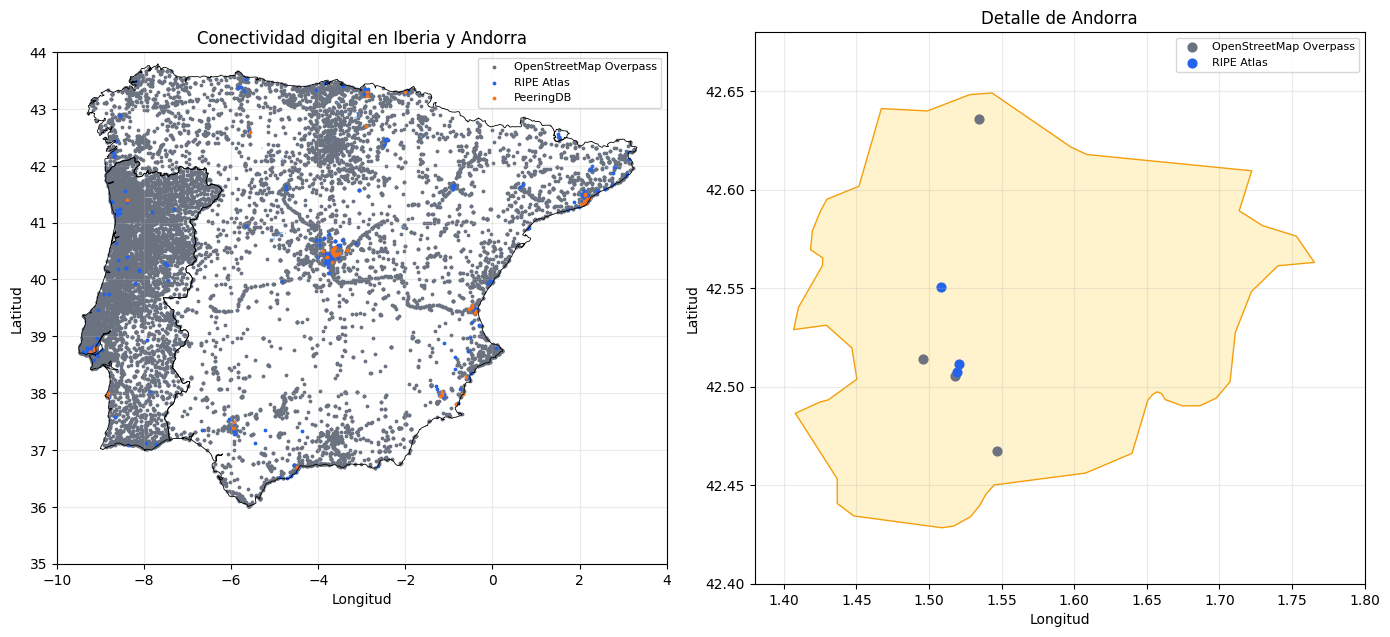

Mapa guardado en: /kaggle/working/07_conectividad_digital_telecomunicaciones_iberia/figuras/mapa_conectividad_digital_iberia_andorra.png


In [16]:
# MAPAS DE CONTROL
ruta_mascara = next(
    INPUT_DIR.rglob(
        "mascara_territorial_iberia_andorra_notebook_07.gpkg"
    )
)
territorio = gpd.read_file(
    ruta_mascara,
    layer="mascara_territorial_iberia_andorra"
)
andorra = territorio[territorio["codigo_pais"] == "AD"]
colores = {
    "OpenStreetMap Overpass": "#6b7280",
    "RIPE Atlas": "#2563eb",
    "PeeringDB": "#f97316"
}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Mapa general
territorio.boundary.plot(ax=ax1, color="black", linewidth=0.6)
osm_lineas_gdf.plot(
    ax=ax1,
    color="#60a5fa",
    linewidth=0.5
)

# Detalle de Andorra
andorra.plot(
    ax=ax2,
    color="#fff3cd",
    edgecolor="#f59e0b"
)
for fuente, color in colores.items():
    datos = nodos_digitales_gdf[
        nodos_digitales_gdf["fuente"] == fuente
    ]
    if not datos.empty:
        datos.plot(
            ax=ax1,
            color=color,
            markersize=3,
            label=fuente
        )
    datos_andorra = nodos_andorra_gdf[
        nodos_andorra_gdf["fuente"] == fuente
    ]
    if not datos_andorra.empty:
        datos_andorra.plot(
            ax=ax2,
            color=color,
            markersize=40,
            label=fuente
        )
ax1.set(
    title="Conectividad digital en Iberia y Andorra",
    xlim=(OESTE, ESTE),
    ylim=(SUR, NORTE)
)
ax2.set(
    title="Detalle de Andorra",
    xlim=(1.38, 1.80),
    ylim=(42.40, 42.68)
)
for ax in (ax1, ax2):
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
ruta_mapa = (
    FIGURAS_DIR /
    "mapa_conectividad_digital_iberia_andorra.png"
)
plt.tight_layout()
plt.savefig(ruta_mapa, dpi=200, bbox_inches="tight")
plt.show()
print("Mapa guardado en:", ruta_mapa)

In [17]:
# DASHBOARD HTML
imagen = base64.b64encode(
    ruta_mapa.read_bytes()
).decode()
ruta_dashboard = (
    DASHBOARD_DIR /
    "dashboard_conectividad_digital_iberia_notebook_07.html"
)
html = f"""
<html>
<head>
<meta charset="UTF-8">
<title>Conectividad digital en Iberia y Andorra</title>
<style>
body{{font-family:Arial;max-width:1200px;margin:auto;padding:25px}}
h1,h2{{color:#1f4e79}}
table{{border-collapse:collapse;width:100%;margin-bottom:20px}}
th,td{{border:1px solid #ddd;padding:6px}}
th{{background:#1f4e79;color:white}}
img{{width:100%}}
</style>
</head>
<body>
<h1>Notebook 07 · Conectividad digital</h1>
<h2>Resumen</h2>
{resumen_bloque_07.to_html(index=False)}
<h2>Nodos por fuente</h2>
{resumen_fuentes.to_html(index=False)}
<h2>Mapa</h2>
<img src="data:image/png;base64,{imagen}">
<h2>Andorra</h2>
{resumen_andorra.to_html(index=False)}
<h2>Trazabilidad</h2>
{trazabilidad_fuentes.to_html(index=False)}
<p>
Los datos representan infraestructura digital observable,
no capacidad, latencia ni disponibilidad comercial.
</p>
</body>
</html>
"""
ruta_dashboard.write_text(html, encoding="utf-8")
print("Dashboard guardado en:", ruta_dashboard)

Dashboard guardado en: /kaggle/working/07_conectividad_digital_telecomunicaciones_iberia/dashboard/dashboard_conectividad_digital_iberia_notebook_07.html


In [18]:
# INVENTARIO Y ZIP FINAL

# Archivos principales ya definidos en celdas anteriores.
archivos_clave = [
    GPKG_DIR / destinos["nodos_4326"],
    GPKG_DIR / destinos["osm_4326"],
    ruta_mapa,
    ruta_dashboard,
    ruta_log_salida,
]

# Comprobar que los productos necesarios existen.
faltantes = [
    ruta.name
    for ruta in archivos_clave
    if not ruta.exists()
]

if faltantes:
    raise FileNotFoundError(
        "Faltan archivos: " + ", ".join(faltantes)
    )

# Inventario final
ruta_inventario = (
    MANIFEST_DIR
    / "inventario_final_notebook_07.csv"
)

# Excluimos el propio inventario para que el resultado sea
# reproducible también al volver a ejecutar la celda.
archivos_inventario = [
    ruta
    for ruta in BASE_DIR.rglob("*")
    if ruta.is_file() and ruta != ruta_inventario
]

inventario = [
    {
        "archivo": str(ruta.relative_to(BASE_DIR)),
        "tamano_bytes": ruta.stat().st_size,
    }
    for ruta in archivos_inventario
]

pd.DataFrame(inventario).to_csv(
    ruta_inventario,
    index=False,
    encoding="utf-8-sig",
)

# ZIP final
ruta_zip = (
    BASE_DIR.parent
    / "07_conectividad_digital_iberia_andorra_final.zip"
)

# Ahora incluimos también el inventario recién generado.
archivos_zip = [
    ruta
    for ruta in BASE_DIR.rglob("*")
    if ruta.is_file()
]

if ruta_zip.exists():
    ruta_zip.unlink()

with zipfile.ZipFile(
    ruta_zip,
    "w",
    zipfile.ZIP_DEFLATED,
) as zipf:
    for ruta in archivos_zip:
        zipf.write(
            ruta,
            ruta.relative_to(BASE_DIR),
        )

# Control del contenido del ZIP
with zipfile.ZipFile(ruta_zip) as zipf:
    contenido = set(zipf.namelist())

estado = True

for ruta in archivos_clave + [ruta_inventario]:
    nombre = str(ruta.relative_to(BASE_DIR))

    if nombre not in contenido:
        estado = False

print("ZIP final:", ruta_zip)
print("Archivos:", len(contenido))
print(
    "Tamaño MB:",
    round(ruta_zip.stat().st_size / 1024**2, 2),
)
print(
    "Estado:",
    "correcto" if estado else "revisar",
)

ZIP final: /kaggle/working/07_conectividad_digital_iberia_andorra_final.zip
Archivos: 18
Tamaño MB: 6.05
Estado: correcto
